<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <p style=" text-align: center; font-size: 32px;">   
   <strong> Optimal Trading Practical Assignment 3: Stochastic Approximation Algorithms Applied to
Optimal Execution </strong></p>
    <p style=" text-align: center; font-size: 25px;"><strong> Master Probabilities & Finance - Ecole Polytechnique and Sorbonne University <strong></p>
  <p style=" text-align: center; font-size: 20px;"> Joseph LECLERC, Carl-Emil JENSEN, Constantin GLEYZE- based from an original LateX of S. Laruelle </p>
</header>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>
<a id="fbm"></a><h1 style="text-align:center;">All algorithms and estimation objectives discussed here are based on the lecture slides Stochastic Approximation Algorithms Applied to Optimal Execution by S. Laruelle, available on GitHub.</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">Import librairies and data</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

In [1]:
# Import of all the required librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor
from datetime import datetime
import sys
import time
from scipy.stats import poisson
#from tqdm import tqdm
pd.set_option('display.max_rows', None)

In [3]:
# We import all the data within a DataFrame structure

canon = pd.read_hdf("CANON.h5")
amazon = pd.read_hdf("AMAZON.h5")
apple = pd.read_hdf("APPLE.h5")
bouygues = pd.read_hdf("BOUYGUES.h5")
lvmh = pd.read_hdf("LVMH.h5")
sanofi = pd.read_hdf("SANOFI.h5")
sony = pd.read_hdf("SONY.h5")
total = pd.read_hdf("TOTAL.h5")
google = pd.read_hdf("GOOGLE.h5")
panasonic = pd.read_hdf("PANASONIC.h5")


# We create geographical list for each stock, as well as a list with their names
list_US = [[google, amazon, apple]]
list_US_name = [['Google', 'Amazon', 'Apple']]
list_FR = [[total, lvmh, bouygues, sanofi]]
list_FR_name = [['Total', 'LVMH', 'Bouygues', 'Sanofi']]
list_JP = [[sony, canon, panasonic]]
list_JP_name = [['Sony', 'Canon', 'Panasonic']]

list_covar_US = [[[google, amazon], [amazon, apple], [google, apple]]]
list_covar_US_name = [[['Google', 'Amazon'], ['Amazon', 'Apple'], ['Google', 'Apple']]]

list_covar_FR = [[[total, lvmh], [total, bouygues], [total, sanofi],[lvmh, bouygues], [lvmh, sanofi], [bouygues, sanofi]]]
list_covar_FR_name = [[['Total', 'LVMH'], ['Total', 'Bouygues'], ['Total', 'Sanofi'],['LVMH', 'Bouygues'], ['LVMH', 'Sanofi'], ['Bouygues', 'Sanofi']]]
list_covar_JP = [[[sony, canon], [sony, panasonic], [canon, panasonic]]]
list_covar_JP_name = [[['Sony', 'Canon'], ['Sony', 'Panasonic'], ['Canon', 'Panasonic']]]

total_list_covar = [list_covar_US[0], list_covar_FR[0], list_covar_JP[0]]
total_list_covar_name = [list_covar_US_name[0], list_covar_FR_name[0], list_covar_JP_name[0]]
total_list = [list_US[0], list_FR[0], list_JP[0]]
total_list_name = [list_US_name[0], list_FR_name[0], list_JP_name[0]]
titles = ["US market", "FR market", "JP market"]
title_US = ["US market"]
title_JP = ["FR market"]
title_FR = ["JP market"]

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">1. Optimal split of orders accross liquidity pools</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

**Code**

In [12]:
def filter_and_give_prices_volume(looked_asset, volume_ref_asset,cotation_place_names,cotation_place_datas,start_date,end_date,period) : 

    """
    Filters and resamples price and volume data over the given time window.

    Parameters
    ----------
    looked_asset: str
                  Name of the asset of interest.
    volume_ref_asset: str
                      Asset used to reference trading volume.
    cotation_place_names: list
                          List of asset or market names.
    cotation_place_datas: list
                          List of DataFrames corresponding to the assets.
    start_date: datetime
                Beginning of the time period.
    end_date: datetime
              End of the time period.
    period: str
            Resampling frequency (e.g., '1Min', '5Min').

    Returns
    -------
    ref_volume_dict: dict
                     Dictionary with resampled traded quantities for reference assets.
    prices_dict: dict
                 Dictionary with resampled average traded prices for all assets.
    """
    
    prices_dict = {}
    ref_volume_dict ={}

    # Loop through each asset and its corresponding data
    for name, data in zip(cotation_place_names, cotation_place_datas): 
        data=data.reset_index() # Ensure flat index
        data['Time'] = pd.to_datetime(data['Time']) # Convert time column to datetime
        data = data[(data['Time'] >= start_date) & (data['Time'] < end_date)] # Filter date range
        data = data.set_index("Time") # Set time as index for resampling
        
        if name!=looked_asset and name!= volume_ref_asset: 
            
            # For other assets, compute resampled average prices only
            prices = data['TradedPrice'].resample(period).mean().fillna(0)
            prices_dict[name] = prices
            
        else : 
            
            # For looked and volume reference assets, store both price and volume
            quantity = data['TradedQty'].resample(period).sum().fillna(0)
            prices = data['TradedPrice'].resample(period).mean().fillna(0)
            ref_volume_dict[name] = quantity
            prices_dict[name] = prices
            
    return ref_volume_dict,prices_dict

def give_di_list(ref_volume_dict, volume_ref_asset, prices_dict, alpha, beta):

    """
    Computes the demand intensity (DI) series for each asset using a weighted
    combination of reference volume and normalized price information.
    
    Parameters
    ----------
    ref_volume_dict: dict
                     Dictionary containing volume time series for reference assets.
    volume_ref_asset: str
                      Key used to extract the main reference volume.
    prices_dict: dict
                 Dictionary mapping each asset to its price series.
    alpha: dict
           Asset-specific alpha values, weighting price contribution.
    beta: dict
          Asset-specific beta scaling the final DI output.
    
    Returns
    -------
    di_dict: dict
             Dictionary mapping asset names to their respective DI time series.
    """

    ref_volume_series = ref_volume_dict[volume_ref_asset] # Volume time series for the reference asset
    ref_volume_mean = ref_volume_series.mean() # Average reference volum

    # Compute average prices to normalize price contribution
    prices_normalization = {key: s.mean() for key, s in prices_dict.items()}
    di_dict = {}

    # Compute DI series for each asset
    for key in prices_dict:
        di_series = beta[key] * (
            (1 - alpha[key]) * ref_volume_series +
            alpha[key] * prices_dict[key] * (ref_volume_mean / prices_normalization[key])
        )
   
        di_dict[key] = di_series
    return di_dict
    
def update_r(V,rho,r_values,D_values,gamma):
    
    """
    Performs one step of the update rule for the allocation vector r based
    on satisfaction conditions and deviation from the average active rho.

    Parameters
    ----------
    V: float
       Total volume to be allocated.
    rho: ndarray
         Sensitivity or price improvement vector.
    r_values: ndarray
              Current allocation vector.
    D_values: ndarray
              Demand intensity values for each asset.
    gamma: float
           Learning rate.

    Returns
    -------
    r_values: ndarray
              Updated allocation vector after applying the adjustment rule.
    """
    
    indicators = (r_values * V < D_values).astype(float) # Assets not yet fully satisfied
    activated_rho = rho * indicators # Keep only rho values where allocation is below demand                   
    average = np.mean(activated_rho) # Average of active rho values 

    # Gradient update rule encouraging allocation where rho is higher than average
    r_values = r_values + gamma * V * (activated_rho - average)
 
    return r_values

def oracle_allocation(V, D_values, rho):

    """
    Computes the optimal allocation vector (oracle) that maximizes executed quantity
    under a greedy strategy, prioritizing assets with high rho.

    Parameters
    ----------
    V: float
       Total volume to be allocated.
    D_values: ndarray
              Demand intensities for each asset at a given time.
    rho: ndarray
         Sensitivity or price improvement vector.

    Returns
    -------
    r_star: ndarray
            Optimal allocation vector maximizing the executed quantity.
    """
    
    N = len(rho)
    r_star = np.zeros(N)
    remaining_room = 1.0
    left_quantities = V
    budget = 1.
    sorted_indices = np.argsort(-rho) # Sort assets by descending rho

    # Return zero allocation if there's nothing to allocate or nothing to satisfy
    if V==0 : 
        return r_star
    if np.sum(D_values)==0:
        return r_star

    # Allocate greedily until budget is exhausted
    for i in sorted_indices:
        r_star[i] = min(budget,D_values[i]/V)
        budget-=r_star[i]
        if budget <=0:
            break
    return r_star

def compute_exec_quantity(V, r, D): 

    """
    Computes the total executed volume as the minimum between allocation
    share and demand share for each asset.

    Parameters
    ----------
    V: float
       Total volume to allocate.
    r: ndarray
       Allocation vector.
    D: ndarray
       Demand intensity vector.

    Returns
    -------
    total_exec: float
                Total executed quantity as a share of V.
    """

    # Manage potential extreme cases
    if V==0 : 
        return 0
    if np.sum(D)==0:
        return 0
        
    D_percent = D/V # Normalize demand per unit of V
    total_exec =0
    for i in range (len(D_percent)):
        total_exec+=min(r[i],D_percent[i])  # Executed = min(offer, demand)
    return total_exec

def compute_economies(V, rho, r, D,P):

    """
    Estimates the cost savings realized from the allocation strategy
    compared to a naive execution at full price.

    Parameters
    ----------
    V: float
       Total volume to be allocated.
    rho: ndarray
         Savings rates (e.g., from midpoint improvement).
    r: ndarray
       Allocation vector.
    D: ndarray
       Demand intensity vector.
    P: float
       Market price used for reference.

    Returns
    -------
    savings_ratio: float
                   Proportion of cost saved versus full price.
    """

    # Manage potential extreme cases
    if V==0 : 
        return 0
    if np.sum(D)==0:
        return 0
    D_percent = D/V
    total_exec=0
    paid=0
    
    for i in range (len(D_percent)):
        quantity = min(r[i],D_percent[i])
        total_exec+=quantity
        paid += (quantity*V)*P*(1-rho[i]) # Effective paid cost
        
    total_paid = paid + max((V-total_exec*V),0)*P # Add cost of unexecuted volume at full price
    
    return ((V*P)-total_paid)/(V*P) # Percent saved vs full cost

def compute_optimal_r_values (ref_volume_dict,prices_dict,looked_asset,D_values_dict,rho,nb_iter):

    """
    Performs iterative allocation updates to optimize the allocation vector r
    based on demand intensity, price improvement (rho), and execution outcomes.

    Parameters
    ----------
    ref_volume_dict: dict
                    Dictionary of reference traded volumes.
    prices_dict: dict
                 Dictionary of asset prices.
    looked_asset: str
                  Asset on which the allocation volume V is based.
    D_values_dict: dict
                   Dictionary of DI time series per asset.
    rho: list or ndarray
         List of savings coefficients per asset.
    nb_iter: int
             Number of training iterations.

    Returns
    -------
    r_trajectory: ndarray
                  Allocation values over time from the learning algorithm.
    r_oracle_trajectory: ndarray
                         Oracle benchmark allocation values.
    r_satisfaction: ndarray
                    Execution ratios from the learning allocation.
    r_oracle_satisfaction: ndarray
                           Execution ratios from the oracle allocation.
    r_economies_percent: ndarray
                         Percentage cost savings from learning allocation.
    r_oracle_economies_percent: ndarray
                                Percentage cost savings from oracle allocation.
    r_economies_nominal: ndarray
                         Monetary savings from learning allocation.
    r_oracle_economies_nominal: ndarray
                                Monetary savings from oracle allocation.
    asset_names: list
                 List of asset identifiers.
    """
    
    rho = np.array(rho) # Convert rho to numpy array in case it's passed as a list

    # Extract volume and price time series for the asset being optimized
    V_values =ref_volume_dict[looked_asset].to_numpy()
    prices = prices_dict[looked_asset].to_numpy()
    
    asset_names = list(D_values_dict.keys()) # Get list of asset names (keys of D_values_dict)

    # Initialization
    N = len(rho)
    r_values = np.ones(N) / N
    r_trajectory = [] # Evolution of r over time
    r_oracle_trajectory = [] # Oracle allocation for comparison
    r_satisfaction = [] # Execution rate of proposed allocation
    r_oracle_satisfaction = [] # Execution rate of oracle allocation
    r_economies_percent = [] # Percentage savings using learned r
    r_oracle_economies_percent = [] # Percentage savings using oracle
    r_economies_nominal = [] # Absolute value of savings in price units
    r_oracle_economies_nominal = [] # Absolute oracle savings
    gamma0 = 2 * 1e-2 # Initial learning rate (decays with iterations)

    # Main training loop
    for i in range (nb_iter): 
        idx = np.random.randint(0, len(V_values)) # Sample a random time index to simulate real-time update (stochastic approximation)

        # Volume to be allocated and market price at that timestamp
        V = V_values[idx]
        price = prices[idx]
        
        D_values = np.array([D_values_dict[name].iloc[idx] for name in asset_names]) # Extract the demand intensity at this time for all assets
        gamma = gamma0 / ((i+1))  # Decaying learning rate: decreases as iterations increase

        # Update allocation vector using learning rule 
        r_values = update_r(V,rho,r_values,D_values,gamma)
        r_trajectory.append(r_values.copy())
        
        r_satisfaction.append(compute_exec_quantity(V,r_values,D_values)) # Satisfaction: proportion of volume executed given current allocation

        # Savings: cost avoided thanks to allocation and improvement rho
        r_economies_percent.append(compute_economies(V,rho,r_values,D_values,price))
        r_economies_nominal.append(V*r_economies_percent[-1]) # Convert to price unit

        # Benchmark using oracle allocation
        r_oracle = oracle_allocation(V, D_values, rho)
        r_oracle_trajectory.append(r_oracle)
        
        r_oracle_satisfaction.append(compute_exec_quantity(V,r_oracle,D_values))
        r_oracle_economies_percent.append(compute_economies(V,rho,r_oracle,D_values,price))
        r_oracle_economies_nominal.append(V*r_oracle_economies_percent[-1])

    # Return all recorded data as numpy arrays (except asset names)
    return np.array(r_trajectory),np.array(r_oracle_trajectory),np.array(r_satisfaction),np.array(r_oracle_satisfaction),np.array(r_economies_percent),np.array(r_oracle_economies_percent),np.array(r_economies_nominal),np.array(r_oracle_economies_nominal),asset_names

def compute_and_plot (names_lists, datas_lists,looked_asset, volume_ref_asset, start_date, end_date, period, alpha, beta, rho,nb_iter=10000,plot=False): 

    """
    High-level function to compute the optimal allocation strategy over time,
    benchmark it against an oracle, and optionally visualize the allocation trajectory.

    Parameters
    ----------
    names_lists: list
            List of lists containing asset names per cotation place.
    datas_lists: list
            List of lists of DataFrames, matching the asset names.
    looked_asset: str
            Asset for which the volume is allocated.
    volume_ref_asset: str
            Asset used as volume reference for DI computation.
    start_date: datetime
            Start of the historical analysis period.
    end_date: datetime
          End of the historical analysis period.
    period: str
         Resampling frequency (e.g., '1Min', '5Min').
    alpha: dict
         Asset-specific alpha values for DI computation.
    beta: dict
        Asset-specific beta values for DI computation.
    rho: list
        List of improvement rates per asset.
    nb_iter: int
         Number of iterations for the learning algorithm.
    plot: bool
        If True, displays the trajectory of r during optimization.

    Returns
    -------
    None
        Prints results to console.
    """

    # Match cotation data for the looked asset
    for idx,names in enumerate(names_lists) : 
        if looked_asset in names : 
            cotation_place_names = names_lists[idx]
            cotation_place_datas = datas_lists[idx]
            
    # Prepare inputs: volume & prices (resampled), then compute DI    
    ref_volume_dict,prices_dict = filter_and_give_prices_volume(looked_asset, volume_ref_asset,cotation_place_names,cotation_place_datas,start_date,end_date,period)
    
    di_dict = give_di_list(ref_volume_dict,volume_ref_asset, prices_dict, alpha, beta)

    # Run the core learning and benchmarking process
    r_values_list,r_oracle_values_list,r_satisfaction,r_oracle_satisfaction, r_economies_percent,r_oracle_economies_percent,r_economies_nominal,r_oracle_economies_nominal,asset_names= compute_optimal_r_values(ref_volume_dict,prices_dict,looked_asset, di_dict, rho,nb_iter)

    # Optional plotting of the learned trajectory for r
    if plot:
        time_steps = range(len(r_values_list))
        r_values_array = np.vstack(r_values_list)  # shape: (T, N)
        for i, name in enumerate(asset_names):
            plt.plot(time_steps, r_values_array[:, i], label=f"r_{i} ({name})")
        plt.title("Evolution of Allocation Weights (r_i)")
        plt.xlabel("Iterations")
        plt.ylabel("Weights")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Print summary statistics for algo and oracle (satisfaction & savings)
    results = {
        "First r_values" : [1/len(r_values_list[0]) for i in range (len(r_values_list[0]))],
        "Last r_values" : [float(np.round(r_values_list[-1][i],3))for i in range (len(r_values_list[-1]))] ,
        "Algo average satisfaction" : f"{np.mean(r_satisfaction)*100:.2f}%",
        "Algo average satisfaction" : f"{np.mean(r_satisfaction)*100:.2f}%",
        "Oracle average satisfaction" : f"{np.mean(r_oracle_satisfaction)*100:.2f}%",
        "Algo average satisfaction (0 excluded)" : f"{np.mean(r_satisfaction[r_satisfaction!=0])*100:.2f}%",
        "Oracle average satisfaction (0 excluded)" : f"{np.mean(r_oracle_satisfaction[r_oracle_satisfaction!=0])*100:.2f}%",
        "Algo average savings" : f"{np.mean(r_economies_percent)*100:.2f}%",
        "Oracle average savings" : f"{np.mean(r_oracle_economies_percent)*100:.2f}%",
        "Algo average savings (no DP trades excluded)" : f"{np.mean(r_economies_percent[r_economies_percent!=0])*100:.2f}%",
        "Oracle average savings (no DP trades excluded)" : f"{np.mean(r_oracle_economies_percent[r_oracle_economies_percent!=0])*100:.2f}%"}
    for key, value in results.items():
        print(f"{key:<50} : {value}")

**Display results**

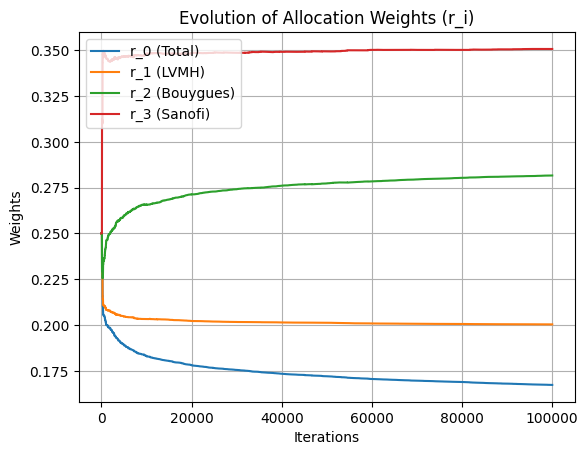

First r_values                                     : [0.25, 0.25, 0.25, 0.25]
Last r_values                                      : [0.167, 0.2, 0.282, 0.351]
Algo average satisfaction                          : 6.50%
Oracle average satisfaction                        : 6.75%
Algo average satisfaction (0 excluded)             : 21.05%
Oracle average satisfaction (0 excluded)           : 21.87%
Algo average savings                               : 0.23%
Oracle average savings                             : 0.25%
Algo average savings (no DP trades excluded)       : 0.75%
Oracle average savings (no DP trades excluded)     : 0.82%


In [13]:
total_bis = total 
total_bis = total_bis.reset_index()
total_bis['Time'] = pd.to_datetime(total_bis['Time'])
start_date = total_bis['Time'].min()
end_date = start_date + pd.Timedelta(days=14)

looked_asset = "Total"
volume_ref_asset = "LVMH"
period = "60s"
list_FR_name = [['Total', 'LVMH', 'Bouygues', 'Sanofi']]

alpha = {'Total':0.4, 'LVMH':0.6, 'Bouygues':0.8, 'Sanofi':0.2}
beta = {'Total':0.1, 'LVMH':0.2, 'Bouygues':0.3, 'Sanofi':0.2}
rho = np.array([0.01,0.02,0.04,0.06])

compute_and_plot (total_list_name, total_list,looked_asset, volume_ref_asset, start_date, end_date, period, alpha, beta, rho,nb_iter=100000,plot=True)

**Comments:**

In practice, we observe that the majority of trades are only marginally executed through dark pools. Due to the chosen modeling approach, it often happens that either almost no part of the trade is executed via dark pools (which is the majority of cases), or the dark pools are able to absorb a large portion, if not all, of the flow. This introduces a certain bias in the statistics presented above.

Indeed, many trades are considered to have no savings because none of them were executed through dark pools and they end up returning to the market. However, this routing to dark pools, the waiting time, and the subsequent execution of orders on the market can have an impact on the execution price (for example, it reduces the time window for optimal execution, pushing volumes to be higher over shorter periods). One can also consider, from a more mathematical perspective, that the overload of r - i.e., sending more than the flow the dark pool can absorb—leads to friction costs or a total absorption by the dark pool but at a less favorable price.

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;">2. Optimal posting prices of limit orders: learning by trading</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

**Code** for estimating $A$ and $a$ using the parametrization $\hat{\lambda}_n(\delta)=Ae^{-a\delta}$ by a linear regression $\log(\hat{\lambda}_n(\delta))=c+\beta\delta+\epsilon$, with $\hat{A}=\exp(\hat{c})$ and $\hat{a}=-\hat{\beta}$

In [14]:
def preprocess_trade_data(trade_df: pd.DataFrame, days_window: int = 14) -> pd.DataFrame:
    
    """
    Preprocess raw trade data:
      - reset_index + rename first column to 'Time'
      - convert 'Time' to datetime
      - take only the first `days_window` days of data
      - drop zero-sign trades and duplicate timestamps
      - compute 'Timediff' (seconds since prior trade)
    """
    
    df = trade_df.copy().reset_index()
    df = df.rename(columns={df.columns[0]: 'Time'})
    df['Time'] = pd.to_datetime(df['Time'])
    start = df['Time'].min()
    end = start + pd.Timedelta(days=days_window)
    df = df[(df['Time'] >= start) & (df['Time'] < end)]
    df = df[df['TradedSign'] != 0]
    df = df[df['Time'].shift(1) != df['Time']]
    df['Timediff'] = df['Time'].diff().dt.total_seconds()
    return df.iloc[1:].reset_index(drop=True)


def times_hit(delta: float, frame: pd.DataFrame, tick: float = 0.01) -> float:
    
    """
    Compute hit-intensity λ for a single block of trades using the estimator on slide 23.
    If no hits or zero elapsed at hits, returns 0.
    """
    
    # elapsed time since first trade in block
    elapsed = (frame['Time'] - frame['Time'].iloc[0]).dt.total_seconds()
    # price level δ ticks below best bid
    level = frame['BidPrice'].iloc[0] - delta * tick
    # indicator of trades hitting that level or better
    where = frame['TradedPrice'] >= level
    # if no hits or zero total elapsed for hits, return 0
    total_elapsed_hits = elapsed[where].sum()
    if total_elapsed_hits == 0:
        return 0.0
    # hit intensity = number of hits divided by elapsed time at hits
    return where.sum() / total_elapsed_hits


def compute_group_lambdas(df: pd.DataFrame, delta_values: np.ndarray, group_size: int = 100, tick: float = 0.01) -> pd.DataFrame:
    
    """
    Compute λ for each δ over non-overlapping index blocks.
    Returns DataFrame indexed by first-trade Time of each block.

    Parameters
    ----------
    df : DataFrame
         Preprocessed trades (with 'Time', 'BidPrice', 'TradedPrice', etc.)
    delta_values : array-like
                   Tick offsets at which to compute intensity (e.g. np.linspace(1,10,5))
    group_size : int
                 Number of trades per block
    tick : float
           Tick size for price levels

    Returns
    -------
    DataFrame
        rows indexed by block timestamps, cols = each δ, values = λ
    """
    
    groups = df.groupby(df.index // group_size)
    timestamps = groups.first()['Time']
    lambdas = {
        δ: groups.apply(lambda block: times_hit(δ, block, tick))
        for δ in delta_values
    }
    out = pd.DataFrame(lambdas)
    out.index = timestamps
    return out


def compute_mean_lambdas(timestamped_lambdas: pd.DataFrame,resample_freq: str = '1d') -> pd.Series:
    
    """
    Resample λ-estimates to daily frequency, then average over days.

    Parameters
    ----------
    timestamped_lambdas : DataFrame
                          λ estimates per block, indexed by timestamp
    resample_freq : str
                    Pandas offset alias for resampling (e.g. '1d')

    Returns
    -------
    Series
        mean λ per δ
    """
    
    daily = timestamped_lambdas.resample(resample_freq).mean()
    return daily.mean()


def fit_log_linear(delta_values: np.ndarray, mean_lambdas: pd.Series, eps: float = 1e-8) -> tuple[float, float, LinearRegression]:
    
    """
    Fit log(λ) = c + b·δ using only valid positive, finite λ.

    Returns:
      A_est = exp(c), a_est = -b, and fitted model.
    """
    
    vals = mean_lambdas.values
    mask = np.isfinite(vals) & (vals > eps)
    if mask.sum() < 2:
        valid = list(zip(delta_values[mask].tolist(), vals[mask].tolist()))
    X = delta_values[mask].reshape(-1, 1)
    y = np.log(vals[mask]).reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    c_est = float(model.intercept_[0])
    b_est = float(model.coef_[0][0])
    return np.exp(c_est), -b_est, model


def plot_log_intensity(delta_values: np.ndarray, mean_lambdas: pd.Series, model: LinearRegression) -> None:
    
    """
    Plot empirical log-λ vs δ and fitted regression line.
    """
    
    vals = mean_lambdas.values
    mask = np.isfinite(vals) & (vals > 0)
    plt.figure(figsize=(8,5))
    plt.plot(delta_values[mask], np.log(vals[mask]), 'o', label='Data (log λ)')
    X_full = delta_values.reshape(-1,1)
    plt.plot(delta_values, model.predict(X_full), label='Linear fit')
    plt.xlabel('δ (ticks)')
    plt.ylabel('log(mean λ)')
    plt.title('Log-Linear Regression for Intensity from the First 5 Limits')
    plt.legend()
    plt.grid(True)
    plt.show()


def intensity_pipeline(trade_df: pd.DataFrame,days_window: int, delta_values: np.ndarray, group_size: int, tick: float = 0.01) -> tuple[pd.Series, float, float, LinearRegression]:
    
    """
    Full pipeline:
    1. preprocess data
    2. compute λ
    3. compute average
    4. fit & plot.
    Raises ValueError if there are fewer than 2 valid λ points.
    """
    
    # 1) Preprocess and group‐by to get blockwise λ estimates
    clean = preprocess_trade_data(trade_df, days_window)
    ts_lams = compute_group_lambdas(clean, delta_values, group_size, tick)
    mean_lambdas = compute_mean_lambdas(ts_lams)

    # 2) Fit the log-linear model
    A_est, a_est, model = fit_log_linear(delta_values, mean_lambdas)

    # 3) Plot the empirical vs fitted
    plot_log_intensity(delta_values, mean_lambdas, model)

    return mean_lambdas, A_est, a_est, model



**Display results**

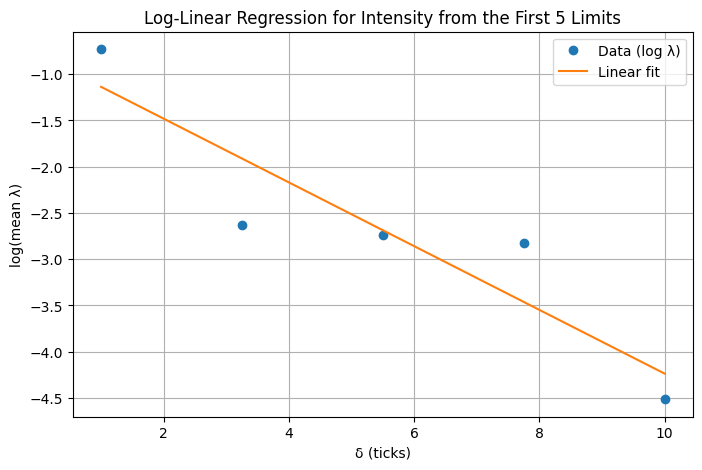

R^2: 0.8358628449854352
Estimated A: 0.45304006130867047
Estimated a: 0.34465222562068926


In [20]:
# We use the function on the AMAZON dataset:
delta_vals = np.linspace(1, 10, 5)
mean_lambdas, A, a, mdl = intensity_pipeline(amazon, days_window=14, delta_values=delta_vals, group_size=100,tick=0.01)

print("R^2:", mdl.score(delta_vals.reshape(-1, 1), np.log(mean_lambdas.values).reshape(-1, 1)))
print("Estimated A:", A)
print("Estimated a:", a)

**Comments**
We note that $R^2\approx 0.84$, indicating that the exponential model explains the vast majority of the observed variation in the log intensity.  
We observe a small deviations suggesting microstructure effects or sampling noise; which could be reduced, e.g. by increasing the number of blocks. Overall, the strong linear trend in the log‐scale confirm that the simple parametrization gives us a reasonable approximation for $A$ and $a$

**Code** for estimating the Poisson hit-intensity λ(δ)=A e^{−aδ}, and constructing the expected cost function $C(\delta)$. Thereafter using the stochastic gradient $C'(\delta)$ to perform stochastic gradient descent to find the optimal quoting distance $\delta^*$ that minimizes total expected slippage and unfilled-order penalty.

In [16]:
def compute_time_step(df: pd.DataFrame, n_init: int = 15) -> float:
    """
    Compute average time delta (dt) over the first n_init trades.

    Parameters
    ----------
    df : DataFrame
        Preprocessed trade DataFrame with 'Time' column as datetime.
    n_init : int
        Number of initial trades to use for dt estimation.

    Returns
    -------
    dt : float
        Average time between successive trades (in seconds).
    """
    frame = df.iloc[:n_init]
    total_time = (frame['Time'].iloc[-1] - frame['Time'].iloc[0]).total_seconds()
    return total_time / (len(frame) - 1)


def compute_lambda(delta: float, price_path: np.ndarray, A: float, a: float, dt: float) -> float:
    """
    Compute cumulative intensity Lambda(δ) along a price path.

    Λ(δ,S) = A * sum_t exp(-a * (S_t - S_0 + δ)) * dt

    Parameters
    ----------
    delta : float
        Quote offset δ from S0.
    price_path : array-like
        Sequence of mid/ask prices S_t.
    A : float
        Intensity scale parameter.
    a : float
        Decay rate in intensity.
    dt : float
        Time increment between samples.

    Returns
    -------
    Lambda : float
        Total Poisson intensity up to final time.
    """
    x = price_path - price_path[0] + delta
    return A * np.sum(np.exp(-a * x) * dt)


def gradient_H(delta: float, price_path: np.ndarray, dt: float, A: float, a: float, Q_T: int, kappa: float) -> float:
    """
    Compute gradient H(δ) of expected cost w.r.t δ.

    where N ~ Poisson(Λ)

    Parameters
    ----------
    delta, price_path, dt, A, a, Q_T, kappa
        see cost and compute_lambda

    Returns
    -------
    H_value : float
        Gradient of cost at δ.
    """
    Λ = compute_lambda(delta, price_path, A, a, dt)
    S0, S_T = price_path[0], price_path[-1]
    sf = poisson.sf(Q_T, Λ)
    cdf = poisson.cdf(Q_T - 1, Λ)
    return -Q_T * sf + (S0 - delta - kappa * S_T) * (-a * Λ) - Λ * cdf


def cost_function(delta: float, price_path: np.ndarray, dt: float, A: float, a: float, Q_T: int, kappa: float) -> float:
    """
    Compute expected execution cost plus terminal penalty.

    E[cost] = (S0 - δ) E[min(N,Q_T)] + kappa*S_T E[max(Q_T - N,0)]
    where N ~ Poisson(Λ)
    """
    Λ = compute_lambda(delta, price_path, A, a, dt)
    S0, S_T = price_path[0], price_path[-1]
    n = np.arange(0, Q_T + 1)
    pmf = poisson.pmf(n, Λ)
    exp_exec = np.sum(np.minimum(Q_T, n) * pmf)
    exp_unexec = np.sum((Q_T - n) * pmf)
    return (S0 - delta) * exp_exec + kappa * S_T * exp_unexec


def check_convexity(delta_grid: np.ndarray, price_path: np.ndarray, dt: float, A: float, a: float, Q_T: int, kappa: float) -> None:
    """
    Plot cost and gradient over a grid of δ values to verify convexity.
    """
    cost_vals = [cost_function(d, price_path, dt, A, a, Q_T, kappa) for d in delta_grid]
    grad_vals = [gradient_H(d, price_path, dt, A, a, Q_T, kappa) for d in delta_grid]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(delta_grid, cost_vals, lw=2, label='Cost C(δ)')
    axes[0].set(xlabel='δ', ylabel='Cost', title='Cost vs δ (Convexity Check)')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(delta_grid, grad_vals, lw=2, label='Gradient H(δ)', color='red')
    axes[1].set(xlabel='δ', ylabel='Gradient', title='Gradient vs δ (Convexity Check)')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def sgd_optimize_delta(price_path: np.ndarray, dt: float, A: float, a: float, Q_T: int, kappa: float, delta_init: float = 1.0, N_iterations: int = 5000,gamma0: float = 1e-1) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Perform SGD to find minimizing δ for the expected cost.

    Returns
    -------
    deltas : array
        δ at each iteration
    costs : array
        cost at each iteration
    delta_opt : float
        final optimized δ
    """
    delta = delta_init
    deltas, costs = [delta], [cost_function(delta, price_path, dt, A, a, Q_T, kappa)]

    for i in range(1, N_iterations+1):
        gamma = gamma0 / (i ** 0.6)
        grad = gradient_H(delta, price_path, dt, A, a, Q_T, kappa)
        delta = delta - gamma * grad
        deltas.append(delta)
        costs.append(cost_function(delta, price_path, dt, A, a, Q_T, kappa))

    return np.array(deltas), np.array(costs), delta


def plot_convergence(deltas: np.ndarray, costs: np.ndarray) -> None:
    """
    Plot SGD convergence of δ and cost over iterations.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: δ‐convergence
    axes[0].plot(deltas, label='δ (SGD)')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('δ')
    axes[0].set_title('SGD Convergence of δ')
    axes[0].grid(True)
    axes[0].legend()

    # Right: cost evolution
    axes[1].plot(costs, label='Cost', color='orange')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Cost')
    axes[1].set_title('SGD Cost Evolution')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def optimization_pipeline(df: pd.DataFrame, A: float, a: float, Q_T: int = 100, kappa: float = 1, n_init: int = 15, delta_grid: np.ndarray = None, **sgd_kwargs) -> dict:
    """
    Full pipeline:
      1. Extract price path and dt from df
      2. (Optional) Check convexity over delta_grid
      3. Run SGD optimization
      4. Plot results

    Parameters
    ----------
    df : DataFrame
        Preprocessed trades with 'AskPrice' and 'Time'.
    A, a, Q_T, kappa : float
        Model parameters.
    n_init : int
        Trades to use for price_path[:n_init] and dt.
    delta_grid : array or None
        Grid for convexity check. If provided, runs check_convexity first.
    sgd_kwargs : dict
        Passed to sgd_optimize_delta (e.g. delta_init, N_iterations, gamma0)

    Returns
    -------
    results : dict
        {
          'deltas': np.ndarray,
          'costs': np.ndarray,
          'delta_opt': float
        }
    """
    # price trajectory
    price_path = df['AskPrice'].values[:n_init]
    dt = compute_time_step(df, n_init)

    # convexity check before optimization
    if delta_grid is not None:
        check_convexity(delta_grid, price_path, dt, A, a, Q_T, kappa)

    # SGD solve
    deltas, costs, delta_opt = sgd_optimize_delta(
        price_path, dt, A, a, Q_T, kappa, **sgd_kwargs
    )
    print(f"Minimizing δ: {delta_opt:.4f}")

    # convergence plots
    plot_convergence(deltas, costs)

    return {'deltas': deltas, 'costs': costs, 'delta_opt': delta_opt}


**Display results**

In [17]:
# Check monotny at the origin 
# 1) Preprocess & extract initial path + dt
df_clean   = preprocess_trade_data(amazon, days_window=14)
n_init     = 15
price_path = df_clean['AskPrice'].values[:n_init]
dt         = compute_time_step(df_clean, n_init)

# 2) Set model parameters
A      = A     
a      = a   
kappa  = 1.0

# Book‐keeping
T   = len(price_path)       
S0  = price_path[0]
ST  = price_path[-1]

# 3) Monotony on κ (slide 36, φ = id so φ' = 1)
max_kappa = (1 + a * S0) / (a * ST)
if kappa <= max_kappa:
    print(f"monotony at the origin satisfied κ = {kappa} ≤ (1 + a·S₀)/(a·S_T) = {max_kappa:.4f}")
else:
    print(f"monotony at the origin not satisfied κ = {kappa} exceeds convexity bound {max_kappa:.4f}; cost may not be convex.")

monotony at the origin satisfied κ = 1.0 ≤ (1 + a·S₀)/(a·S_T) = 1.0158


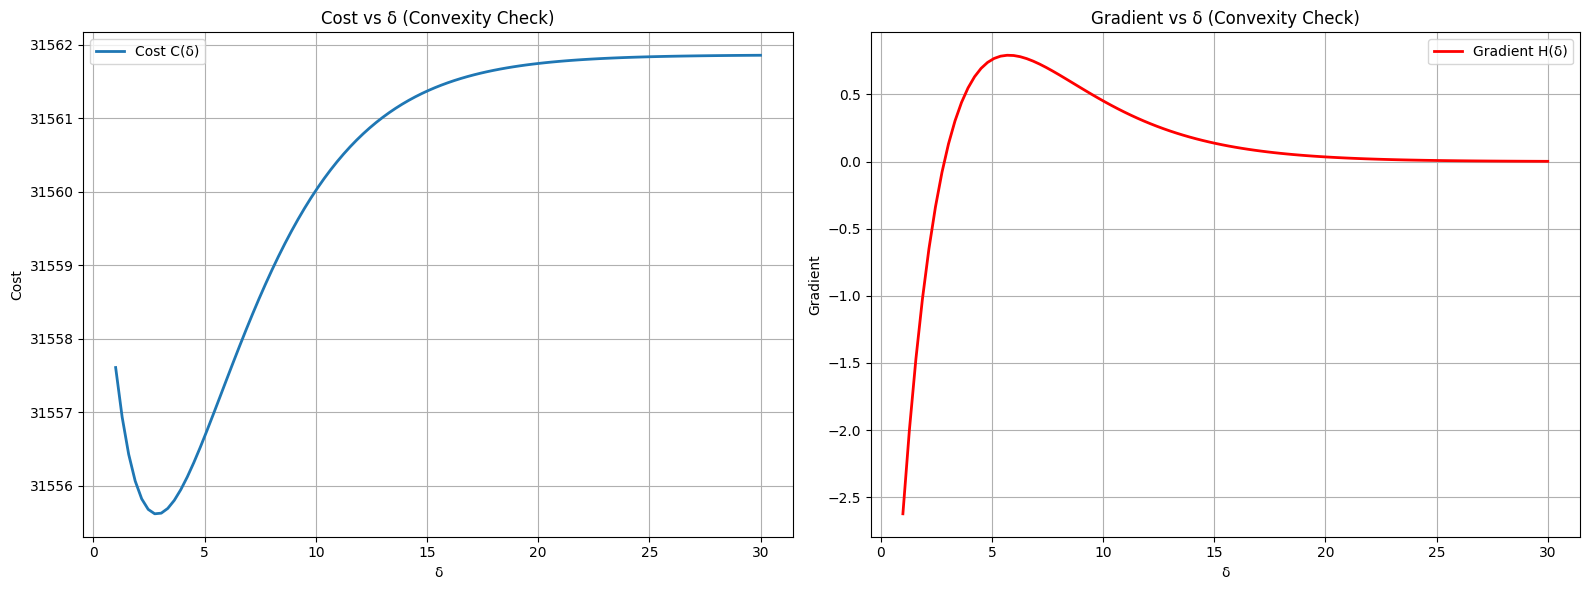

Minimizing δ: 2.8570


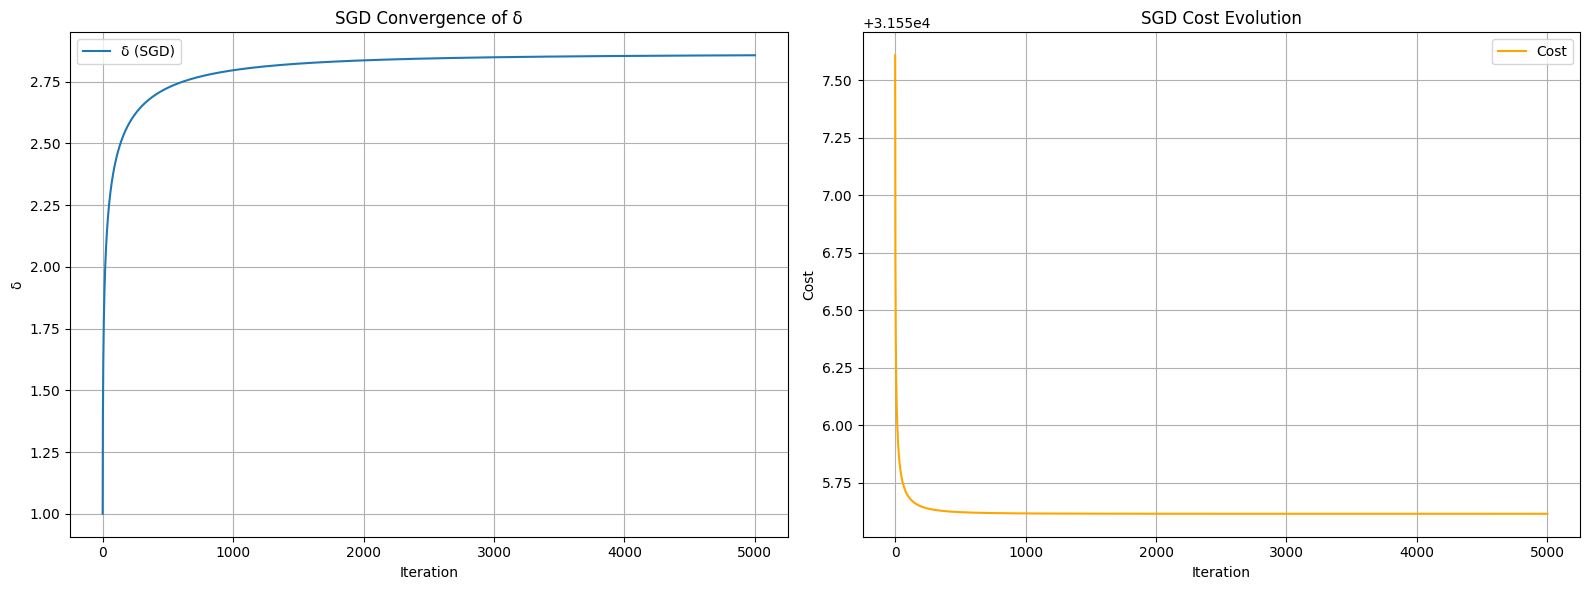

Optimized δ: 2.856997289438972


In [18]:
#we use the function on the AMAZON dataset contuínuing from the previous example:
# First, preprocess the raw trade data:
df = preprocess_trade_data(amazon, days_window=14)
# Then run optimization, including convexity check before SGD:
results = optimization_pipeline(
    df,
    A=A,
    a=a,
    Q_T=174,
    kappa=1,
    n_init=15,
    delta_grid=np.linspace(1,30,100),
    delta_init=1,
    N_iterations=5000,
    gamma0=1e-1
)
print(f"Optimized δ: {results['delta_opt']}")

**Comments:**

By checking convexity and monotony at the origin of the cost function and running a stochastic gradient descent with a decaying step size we saw our algorithm robustly converging to
The algorithm robustly converged to  
$$
δ^* \approx 2.857\text{ ticks},
$$
Solving
$$
\min_{\delta>0}C(\delta)\,.
$$ 
This approach can accommodate other penalty functions $\phi$ and be applied to different assets, so long as convexity and monotonicity at the origin are preserved. In our case—using the first two weeks of Amazon trade data—we find that posting roughly three ticks away from the best bid optimally balances execution probability against price improvement. At this offset, the marginal loss in fill probability is exactly offset by the marginal gain in execution price, minimizing total expected slippage plus any unfilled-order penalty. 